# Time Series Diagnostics

After exploratory analysis, we now examine the statistical properties of financial returns.

Objectives:
1. Test stationarity of returns
2. Analyze autocorrelation structure
3. Examine randomness of mean process
4. Detect volatility clustering
5. Identify ARCH effects

These steps help determine appropriate models for volatility forecasting.

## Step 1
### Stationarity Test (ADF)

The Augmented Dickey-Fuller test checks whether the time series is stationary.

- Null hypothesis: series is non-stationary
- If p-value < 0.05 → reject null → stationary

Result: Returns are typically stationary, which is a key assumption for many time series models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

sp500.head()

,Open,High,Low,Close,Volume,log_return,vol_30
Date,,,,,,,
2014-01-03,149.238532,149.539900,148.749847,148.961609,81390600,-0.000164,NaN
2014-01-06,149.450282,149.507290,148.301852,148.529907,108028200,-0.002902,NaN
2014-01-07,149.124474,149.694612,149.010446,149.442123,86144200,0.006123,NaN
2014-01-08,149.417742,149.727251,148.961631,149.474762,96582300,0.000218,NaN
2014-01-09,149.955259,149.971552,148.888282,149.572449,90683400,0.000653,NaN


In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sp500["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -18.02564033713839
p-value: 2.6864479950847978e-30


step 2
### ACF of Returns

The autocorrelation of returns is generally very low.

This suggests:
- returns behave like white noise
- past returns do not predict future returns

This is consistent with the Efficient Market Hypothesis.

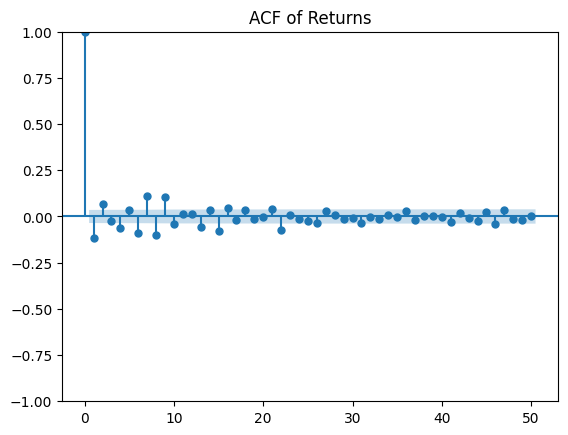

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sp500["log_return"], lags=50)
plt.title("ACF of Returns")
plt.show()

step 3
### PACF of Returns

The PACF confirms that there is no strong lag-based structure in returns.

This indicates:
- mean process does not follow AR patterns
- supports modeling mean as constant or random noise

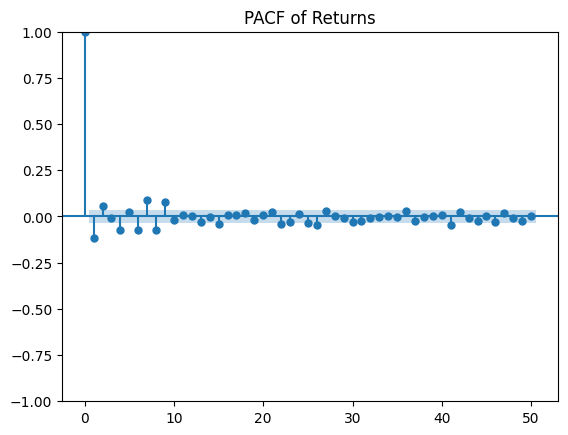

In [5]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(sp500["log_return"], lags=50)
plt.title("PACF of Returns")
plt.show()

step 4
### Squared Returns ACF

Unlike raw returns, squared returns show significant autocorrelation.

This indicates:
- volatility clustering
- periods of high volatility follow high volatility

This is a key stylized fact of financial markets.

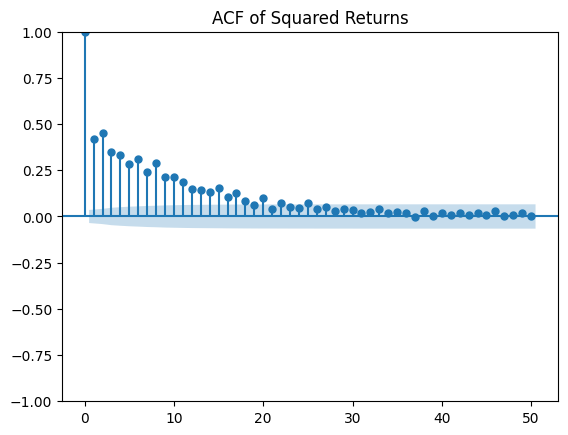

In [6]:
plot_acf(sp500["log_return"]**2, lags=50)
plt.title("ACF of Squared Returns")
plt.show()

step 5
### ARCH Effect Detection

The ARCH test checks for time-varying volatility.

- Null hypothesis: no ARCH effects
- If p-value < 0.05 → ARCH effects present

Result:
Presence of ARCH effects confirms that volatility is not constant over time.

This justifies the use of ARCH/GARCH models.

In [7]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(sp500["log_return"])

print("ARCH Test Statistic:", arch_test[0])
print("p-value:", arch_test[1])

ARCH Test Statistic: 914.9471222153883
p-value: 3.8620257933348176e-190


## Key Findings

1. Returns are stationary
2. Returns show little autocorrelation (white noise behavior)
3. Squared returns show strong autocorrelation
4. Volatility clustering is present
5. ARCH effects are statistically significant

Conclusion:
These findings strongly support the use of GARCH-type models for volatility forecasting.